In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,       # Vocabulary size
    "context_length": 1024,    # Context length
    "emb_dim": 768,            # Embedding dimension
    "n_heads": 12,             # Number of attention heads
    "n_layers": 12,            # Number of layers
    "drop_rate_attn": 0.1,     # Dropout rate for multi-head attention 
    "drop_rate_shortcut": 0.1, # Dropout rate for shortcut connections 
    "drop_rate_emb": 0.1,      # Dropout rate for embedding layer
    "qkv_bias": False          # Query-Key-Value bias
}

In [1]:
import torch
import torch.nn as nn
import tiktoken

In [3]:
# from chapter 3

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal = 1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)
        queries = queries.transpose(1, 2)

        attn_scores = queries @ keys.transpose(2,3)
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax( attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1,2)

        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)

        context_vec = self.out_proj(context_vec)
        return context_vec

In [4]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [10]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x* ( 1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0/torch.pi)) 
            * (x + 0.044715 * torch.pow(x, 3))))

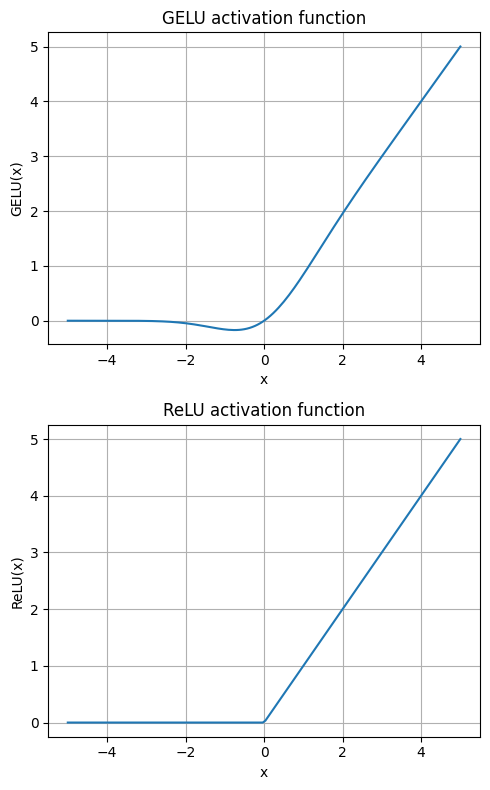

In [11]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-5, 5, 150)    
y_gelu, y_relu = gelu(x), relu(x)
# Make the figure taller
plt.figure(figsize=(5, 8))

for i, (y, label) in enumerate(zip(
        [y_gelu, y_relu], 
        ["GELU", "ReLU"]), 1):
    # Change subplot layout to vertical (2 rows, 1 column)
    plt.subplot(2, 1, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [28]:
# helper function
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])

    criterion = nn.MSELoss()
    loss = criterion(output, target)

    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of " 
                  f"{param.grad.abs().mean().item()}")

In [29]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[i], 
                                    layer_sizes[i+1]), GELU())
            for i in range(len(layer_sizes) - 1)
        ])


    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)        
            if self.use_shortcut and x.shape == layer_output.shape:   
                x = x + layer_output
            else:
                x = layer_output
        return x

layer_sizes = [4, 4, 4, 4, 4, 4, 1]  
sample_input = torch.tensor([[0.6, 0.3, 0., -0.3]])

print("Model without shortcut")
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

print("Model with shortcut")
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

Model without shortcut
layers.0.0.weight has gradient mean of 0.00011171719233971089
layers.1.0.weight has gradient mean of 0.0002804722171276808
layers.2.0.weight has gradient mean of 0.0004977626376785338
layers.3.0.weight has gradient mean of 0.006228148005902767
layers.4.0.weight has gradient mean of 0.015021126717329025
layers.5.0.weight has gradient mean of 0.056009769439697266
Model with shortcut
layers.0.0.weight has gradient mean of 0.002781738992780447
layers.1.0.weight has gradient mean of 0.0027199035976082087
layers.2.0.weight has gradient mean of 0.0002717698225751519
layers.3.0.weight has gradient mean of 0.001978363608941436
layers.4.0.weight has gradient mean of 0.005832917056977749
layers.5.0.weight has gradient mean of 0.04165162891149521


In [30]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate_attn"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate_shortcut"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

In [31]:
# Exercise 1
ff = FeedForward(GPT_CONFIG_124M)
total_params_ff = sum(p.numel() for p in ff.parameters())
print(f"Total number of feed forward parameters: {total_params_ff:,}")

att = MultiHeadAttention(
            d_in=GPT_CONFIG_124M["emb_dim"],
            d_out=GPT_CONFIG_124M["emb_dim"],
            context_length=GPT_CONFIG_124M["context_length"],
            num_heads=GPT_CONFIG_124M["n_heads"],
            dropout=GPT_CONFIG_124M["drop_rate_attn"],
            qkv_bias=GPT_CONFIG_124M["qkv_bias"],
        )
total_params_att = sum(p.numel() for p in att.parameters())
print(f"Total number of attention parameters: {total_params_att:,}")

#the feed forward module contains approximately twice as many parameters as the attention module

Total number of feed forward parameters: 4,722,432
Total number of attention parameters: 2,360,064


In [32]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate_emb"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [48]:
# exercuse 2
def print_model_info(model, model_name):
    total_params = sum(p.numel() for p in model.parameters())
    total_params_gpt2 = (total_params - sum(p.numel() 
                                            for p in model.out_head.parameters()))
    total_size_bytes = total_params * 4
    total_size_mb = total_size_bytes / (1024 *1024)
    
    print(model_name)
    print(f"Total number of parameters: {total_params:,}")
    print(f"Number of trainable parameters "
          "considering weight tying: {total_params_gpt2:,}")
    print(f"Total size of the model: {total_size_mb: .2f} MB")

model_small = GPTModel(GPT_CONFIG_124M)
print_model_info(model_small, "GPT2 Small")

GPT2_CONFIG_MEDIUM =  GPT_CONFIG_124M.copy()
GPT2_CONFIG_MEDIUM["emb_dim"] = 1024
GPT2_CONFIG_MEDIUM["n_layers"] = 24
GPT2_CONFIG_MEDIUM["n_heads"] = 16


model_medium = GPTModel(GPT2_CONFIG_MEDIUM)
print_model_info(model_medium, "GPT2 Medium")

GPT2_CONFIG_LARGE = GPT_CONFIG_124M.copy()
GPT2_CONFIG_LARGE["emb_dim"] = 1280
GPT2_CONFIG_LARGE["n_layers"] = 36
GPT2_CONFIG_LARGE["n_heads"] = 20

model_large = GPTModel(GPT2_CONFIG_LARGE)
print_model_info(model_large, "GPT2 Large")

GPT2_CONFIG_XL = GPT_CONFIG_124M.copy()
GPT2_CONFIG_XL["emb_dim"] = 1600
GPT2_CONFIG_XL["n_layers"] = 48
GPT2_CONFIG_XL["n_heads"] = 25

model_xl = GPTModel(GPT2_CONFIG_XL)
print_model_info(model_xl, "GPT2 XL")

GPT2 Small
Total number of parameters: 163,009,536
Number of trainable parameters considering weight tying: {total_params_gpt2:,}
Total size of the model:  621.83 MB
GPT2 Medium
Total number of parameters: 406,212,608
Number of trainable parameters considering weight tying: {total_params_gpt2:,}
Total size of the model:  1549.58 MB
GPT2 Large
Total number of parameters: 838,220,800
Number of trainable parameters considering weight tying: {total_params_gpt2:,}
Total size of the model:  3197.56 MB
GPT2 XL
Total number of parameters: 1,637,792,000
Number of trainable parameters considering weight tying: {total_params_gpt2:,}
Total size of the model:  6247.68 MB


In [43]:
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "The Education is important"
txt2 = "People together can do"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[ 464, 7868,  318, 1593],
        [8061, 1978,  460,  466]])


In [44]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print("\nOutput shape:", out.shape)
print(out)


Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.1718,  0.0274,  0.1183,  ...,  0.4980,  0.4469, -0.6023],
         [ 0.4501, -1.0105, -0.1092,  ...,  0.3935,  0.2701, -0.4101],
         [ 1.1388, -0.9765, -0.1087,  ...,  0.0982, -0.1706, -0.3320],
         [-0.1239, -0.6407,  0.4888,  ...,  0.4633, -0.3827,  0.4373]],

        [[-0.1805, -0.4337, -0.1432,  ..., -0.2804,  0.0203,  0.0932],
         [ 0.8543, -0.0917,  0.0781,  ..., -0.4479,  0.4969,  0.0923],
         [ 0.8241,  0.7153,  0.7567,  ...,  0.0742,  0.2338, -0.4117],
         [-0.6143,  0.1730, -0.2795,  ...,  0.5512,  0.2355, -0.3868]]],
       grad_fn=<UnsafeViewBackward0>)


In [45]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [49]:
model.eval()
out = generate_text_simple(model=model, idx = batch, max_new_tokens = 7, context_size=GPT_CONFIG_124M["context_length"])
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[  464,  7868,   318,  1593,  4301, 10091, 20583,  2881, 14158, 34093,
         43042],
        [ 8061,  1978,   460,   466, 31387, 18590,   154, 36413, 47978, 38808,
         35308]])
Output length: 11


In [50]:
for idx in out:
    decoded_text = tokenizer.decode(idx.tolist())
    print(decoded_text)

The Education is important criminal?) curriculumhern ic fres Ic
People together can doftime intensive� REALLY tumble Nay habitats
